C:\Users\arthe\AppData\Local\Temp\ipykernel_23844\4079771822.py:79: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\arthe\anaconda3\envs\lab-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


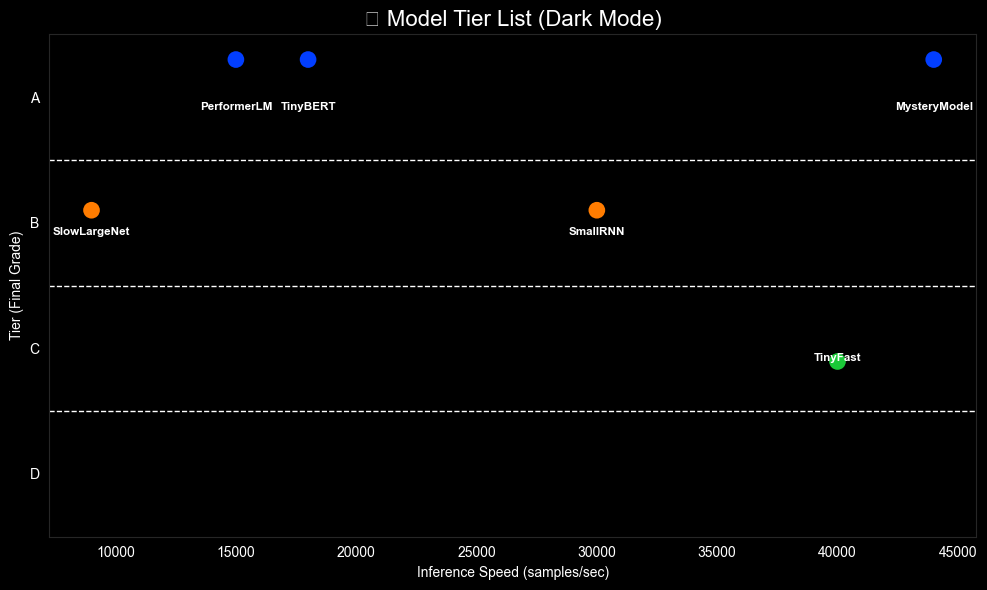

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data with some "unknown" inference times
models = [
    {"Model": "PerformerLM", "Accuracy": 0.923, "AUC": 0.96, "Speed": 15000, "Params": 12e6, "Final_Score": "A"},
    {"Model": "TinyBERT", "Accuracy": 0.915, "AUC": 0.95, "Speed": 18000, "Params": 9e6, "Final_Score": "A-"},
    {"Model": "SmallRNN", "Accuracy": 0.871, "AUC": 0.90, "Speed": 30000, "Params": 2e6, "Final_Score": "B+"},
    {"Model": "SlowLargeNet", "Accuracy": 0.88, "AUC": 0.91, "Speed": 9000, "Params": 20e6, "Final_Score": "B"},
    {"Model": "TinyFast", "Accuracy": 0.84, "AUC": 0.87, "Speed": 40000, "Params": 1.5e6, "Final_Score": "C"},
    {"Model": "MysteryModel", "Accuracy": 0.85, "AUC": 0.89, "Speed": None, "Params": 10e6, "Final_Score": "A"},  # Unknown Inference Time
]

# Create DataFrame
df = pd.DataFrame(models)

# Map Final Scores into pure A, B, C tiers
tier_mapping = {
    "A": "A", "A-": "A",
    "B+": "B", "B": "B",
    "C+": "C", "C": "C",
    "D": "D"
}
df["Tier"] = df["Final_Score"].map(tier_mapping)

# Set ordered categories
tiers_order = ["A", "B", "C", "D"]
df["Tier"] = pd.Categorical(df["Tier"], categories=tiers_order, ordered=True)

# Handle unknown inference times by setting them to the maximum speed value
max_speed = df["Speed"].max()  # Get the max speed from known models
df["Speed"].fillna(max_speed * 1.1, inplace=True)  # Place unknown models slightly to the right

# Create plot with manual dark background
plt.figure(figsize=(10, 6))
plt.gcf().patch.set_facecolor('black')  # Set the figure background to black
plt.gca().patch.set_facecolor('black')  # Set the axes background to black

# Strip plot
sns.stripplot(
    x="Speed", 
    y="Tier", 
    data=df, 
    size=12, 
    hue="Tier", 
    palette="bright",  # Bright colors for dark background
    jitter=False, 
    dodge=True
)

# Annotate model names
for i in range(len(df)):
    plt.text(
        df["Speed"].iloc[i], 
        df["Tier"].cat.codes.iloc[i] + 0.1, 
        df["Model"].iloc[i], 
        horizontalalignment='center', 
        size='small', 
        color='white', 
        weight='semibold'
    )

# Add horizontal lines to separate the tiers
for tier_index in range(1, len(tiers_order)):  # Start from 1 to avoid a line at the top
    plt.axhline(y=tier_index - 0.5, color='white', linestyle='--', linewidth=1)

# Set titles and labels with white text
plt.title("🚀 Model Tier List (Dark Mode)", color='white', fontsize=16)
plt.xlabel("Inference Speed (samples/sec)", color='white')
plt.ylabel("Tier (Final Grade)", color='white')
plt.xticks(color='white')
plt.yticks(color='white')

# Remove legend
plt.legend([],[], frameon=False)  

# Tight layout
plt.tight_layout()

# Show plot
plt.show()
